In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for professional charts
sns.set_theme(style="whitegrid")

# 1. Load the data
df = pd.read_csv('../data/HHS_Unaccompanied_Alien_Children_Program.csv')

# 2. Clean column names (strip whitespace)
df.columns = df.columns.str.strip()

# 3. Clean 'Children in HHS Care' (Remove commas and convert to numeric)
df['Children in HHS Care'] = df['Children in HHS Care'].replace({',': ''}, regex=True)
df['Children in HHS Care'] = pd.to_numeric(df['Children in HHS Care'])

# 4. Parse Dates and sort chronologically
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').dropna(subset=['Date'])

# 5. Fix the Missing Dates (Crucial for Time-Series)
# Set Date as the index
df = df.set_index('Date')

# Create a complete daily date range from the first to the last date
full_date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')

# Reindex the dataframe to this full range (this will create NaN values for missing days)
df_clean = df.reindex(full_date_range)

# Interpolate the missing values linearly 
# (e.g., if Day 1 is 100 and Day 3 is 110, Day 2 becomes 105)
df_clean = df_clean.interpolate(method='linear')

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")
print(f"Missing values remaining:\n{df_clean.isnull().sum()}")

# Save this clean dataset for the next phase
df_clean.to_csv('../data/HHS_UAC_Cleaned.csv')

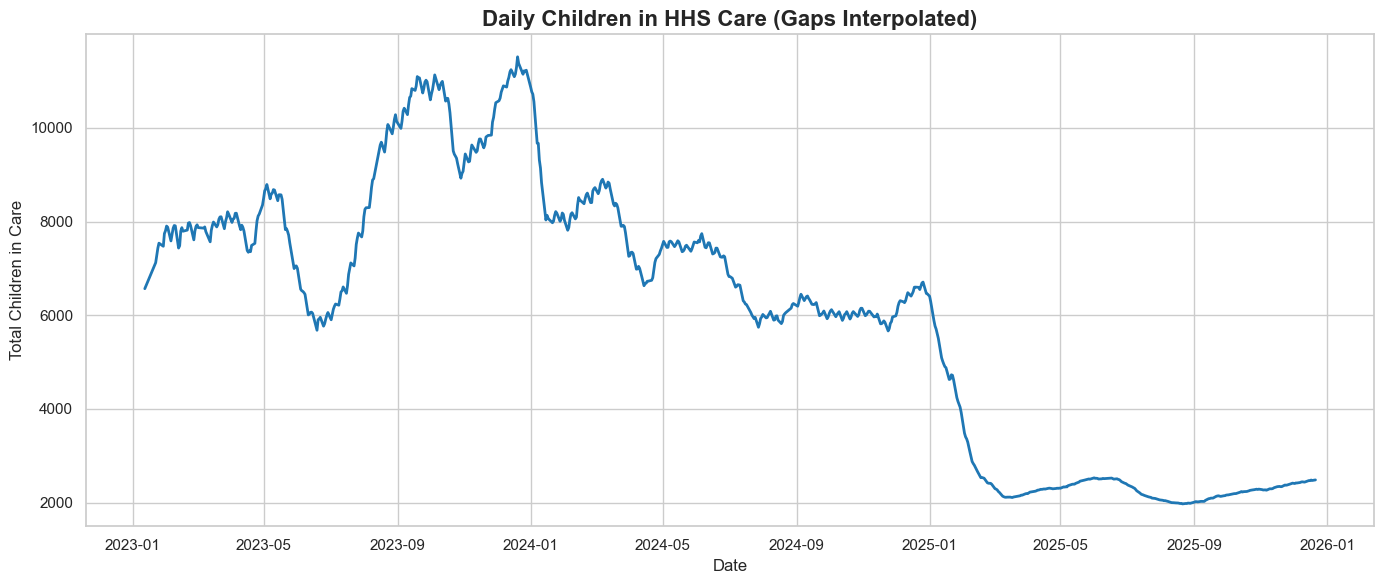

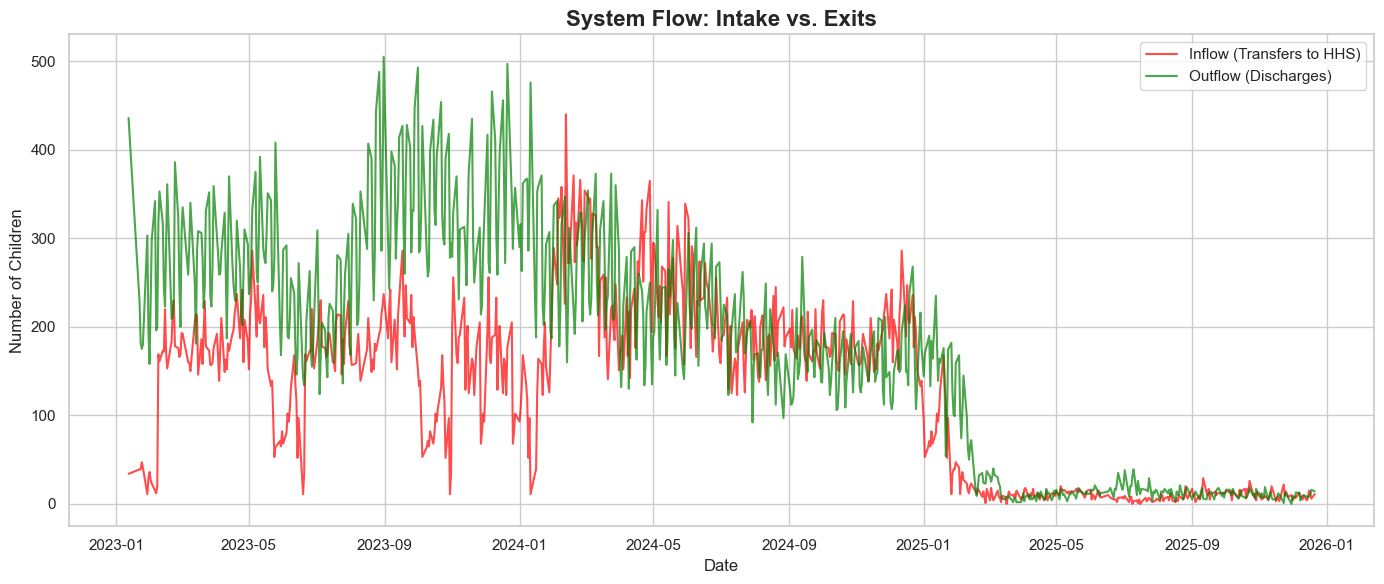

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. LOAD RAW DATA (Using a safer path that looks in the current folder OR the data folder)
try:
    df = pd.read_csv('data/HHS_Unaccompanied_Alien_Children_Program.csv')
except FileNotFoundError:
    df = pd.read_csv('../data/HHS_Unaccompanied_Alien_Children_Program.csv')

# 2. CLEAN DATA
df.columns = df.columns.str.strip()
df['Children in HHS Care'] = df['Children in HHS Care'].replace({',': ''}, regex=True)
df['Children in HHS Care'] = pd.to_numeric(df['Children in HHS Care'])
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').dropna(subset=['Date'])

# 3. INTERPOLATE GAPS
df = df.set_index('Date')
full_date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
df_clean = df.reindex(full_date_range)
df_clean = df_clean.interpolate(method='linear')

# ==========================================
# CHART 1: The Total Care Load
# ==========================================
plt.figure(figsize=(14, 6))
plt.plot(df_clean.index, df_clean['Children in HHS Care'], color='#1f77b4', linewidth=2)
plt.title('Daily Children in HHS Care (Gaps Interpolated)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Children in Care', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# CHART 2: System Flow (Inflow vs. Outflow)
# ==========================================
plt.figure(figsize=(14, 6))
plt.plot(df_clean.index, df_clean['Children transferred out of CBP custody'], 
         label='Inflow (Transfers to HHS)', color='red', alpha=0.7)
plt.plot(df_clean.index, df_clean['Children discharged from HHS Care'], 
         label='Outflow (Discharges)', color='green', alpha=0.7)
plt.title('System Flow: Intake vs. Exits', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Children', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()